In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("COVID-19_Dataset.csv")

print(df.head())

  Province/State         Country Date last updated  Confirmed  Suspected  \
0       Shanghai  Mainland China         1/21/2020        9.0       10.0   
1         Yunnan  Mainland China         1/21/2020        1.0        NaN   
2        Beijing  Mainland China         1/21/2020       10.0        NaN   
3         Taiwan  Mainland China         1/21/2020        1.0        NaN   
4          Jilin  Mainland China         1/21/2020        NaN        1.0   

   Recovered  Deaths  
0        NaN     NaN  
1        NaN     NaN  
2        NaN     NaN  
3        NaN     NaN  
4        NaN     NaN  


In [8]:
df = pd.read_csv("COVID-19_Dataset.csv")

In [9]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns)

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(368, 7)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Province/State     304 non-null    str    
 1   Country            368 non-null    str    
 2   Date last updated  368 non-null    str    
 3   Confirmed          339 non-null    float64
 4   Suspected          88 non-null     float64
 5   Recovered          36 non-null     float64
 6   Deaths             24 non-null     float64
dtypes: float64(4), str(3)
memory usage: 20.3 KB
None

Column Names:
Index(['Province/State', 'Country', 'Date last updated', 'Confirmed',
       'Suspected', 'Recovered', 'Deaths'],
      dtype='str')

Statistical Summary:
         Confirmed   Suspected  Recovered     Deaths
count   339.000000   88.000000  36.000000  24.000000
mean     30.351032   22.613636   7.722222  11.041667
std     112.556169   48.177696  13.306521  17.

In [10]:
print(df.isnull().sum())

Province/State        64
Country                0
Date last updated      0
Confirmed             29
Suspected            280
Recovered            332
Deaths               344
dtype: int64


In [11]:
df["Province/State"] = df["Province/State"].fillna("Unknown")

df["Confirmed"] = df["Confirmed"].fillna(0)
df["Suspected"] = df["Suspected"].fillna(0)
df["Recovered"] = df["Recovered"].fillna(0)
df["Deaths"] = df["Deaths"].fillna(0)

In [12]:
df["Date last updated"] = pd.to_datetime(
    df["Date last updated"],
    errors="coerce"
)

print(df.head())

  Province/State         Country Date last updated  Confirmed  Suspected  \
0       Shanghai  Mainland China        2020-01-21        9.0       10.0   
1         Yunnan  Mainland China        2020-01-21        1.0        0.0   
2        Beijing  Mainland China        2020-01-21       10.0        0.0   
3         Taiwan  Mainland China        2020-01-21        1.0        0.0   
4          Jilin  Mainland China        2020-01-21        0.0        1.0   

   Recovered  Deaths  
0        0.0     0.0  
1        0.0     0.0  
2        0.0     0.0  
3        0.0     0.0  
4        0.0     0.0  


In [13]:
print(df.isnull().sum())

print(df.describe())

Province/State         0
Country                0
Date last updated    341
Confirmed              0
Suspected              0
Recovered              0
Deaths                 0
dtype: int64
         Date last updated    Confirmed   Suspected   Recovered      Deaths
count                   27   368.000000  368.000000  368.000000  368.000000
mean   2020-01-21 00:00:00    27.959239    5.407609    0.755435    0.720109
min    2020-01-21 00:00:00     0.000000    0.000000    0.000000    0.000000
25%    2020-01-21 00:00:00     2.000000    0.000000    0.000000    0.000000
50%    2020-01-21 00:00:00     4.000000    0.000000    0.000000    0.000000
75%    2020-01-21 00:00:00    16.000000    0.000000    0.000000    0.000000
max    2020-01-21 00:00:00  1058.000000  244.000000   42.000000   52.000000
std                    NaN   108.327568   25.367858    4.707808    5.166485


In [14]:
df["Recovery Rate"] = np.where(
    df["Confirmed"] > 0,
    (df["Recovered"] / df["Confirmed"]) * 100,
    0
)

df["Death Rate"] = np.where(
    df["Confirmed"] > 0,
    (df["Deaths"] / df["Confirmed"]) * 100,
    0
)

df["Active Cases"] = (
    df["Confirmed"]
    - df["Recovered"]
    - df["Deaths"]
)

print(df.head())

  Province/State         Country Date last updated  Confirmed  Suspected  \
0       Shanghai  Mainland China        2020-01-21        9.0       10.0   
1         Yunnan  Mainland China        2020-01-21        1.0        0.0   
2        Beijing  Mainland China        2020-01-21       10.0        0.0   
3         Taiwan  Mainland China        2020-01-21        1.0        0.0   
4          Jilin  Mainland China        2020-01-21        0.0        1.0   

   Recovered  Deaths  Recovery Rate  Death Rate  Active Cases  
0        0.0     0.0            0.0         0.0           9.0  
1        0.0     0.0            0.0         0.0           1.0  
2        0.0     0.0            0.0         0.0          10.0  
3        0.0     0.0            0.0         0.0           1.0  
4        0.0     0.0            0.0         0.0           0.0  


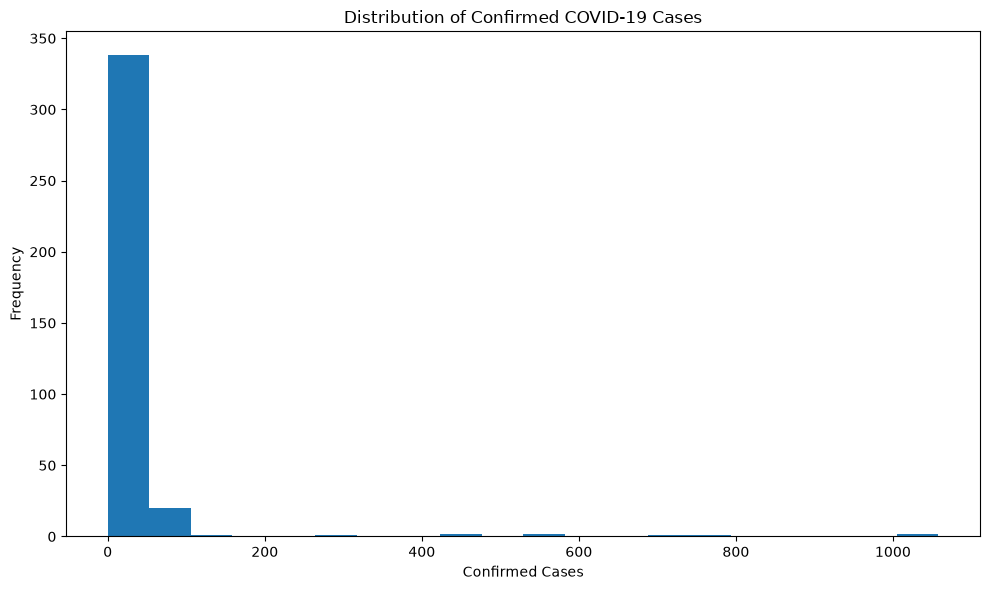

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(df["Confirmed"], bins=20)

plt.title("Distribution of Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

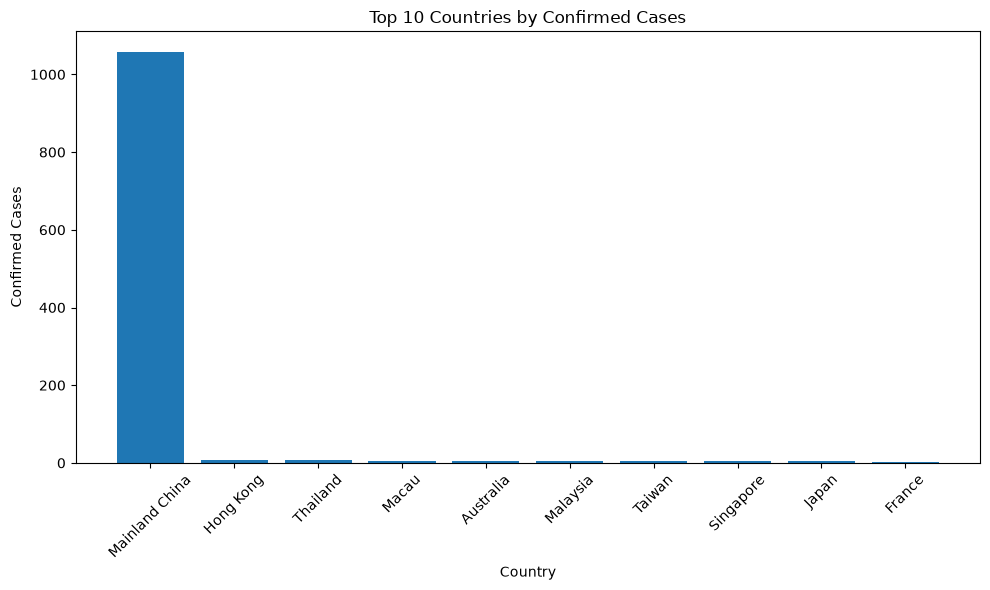

In [16]:
country_confirmed = (
    df.groupby("Country")["Confirmed"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    country_confirmed.index,
    country_confirmed.values
)

plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

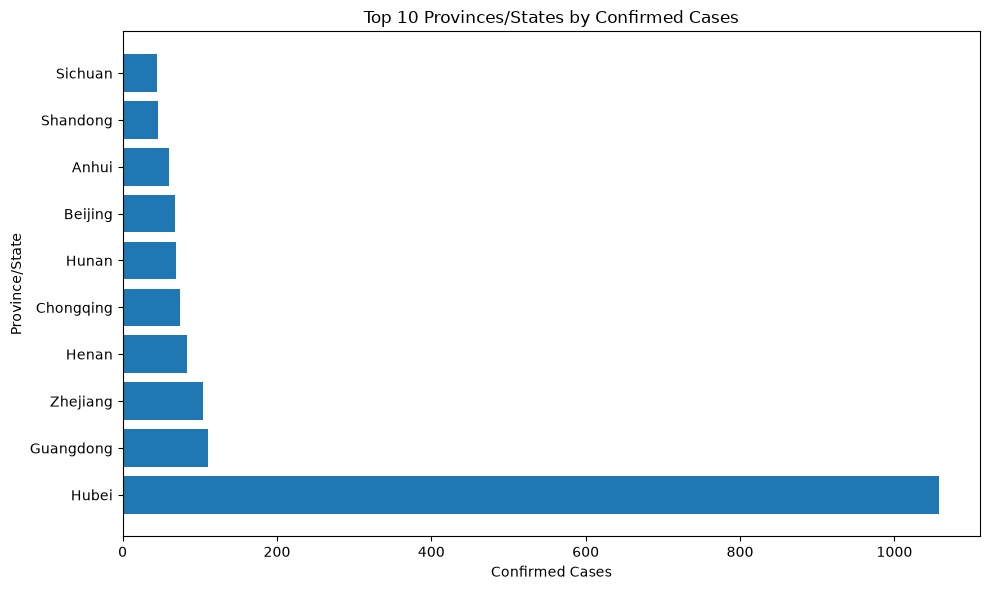

In [17]:
state_confirmed = (
    df.groupby("Province/State")["Confirmed"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    state_confirmed.index,
    state_confirmed.values
)

plt.title("Top 10 Provinces/States by Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Province/State")

plt.tight_layout()
plt.show()

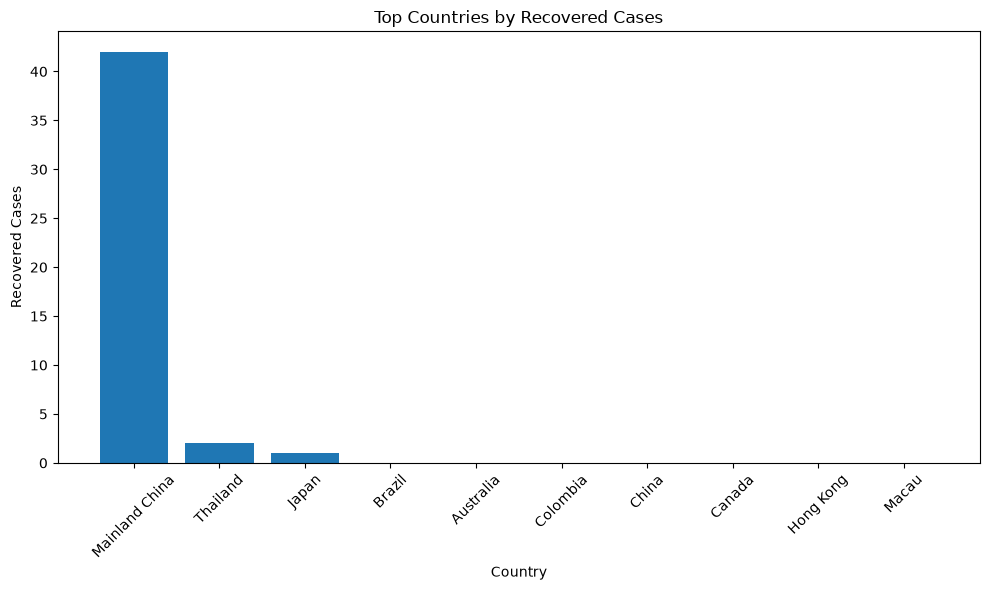

In [18]:
country_recovered = (
    df.groupby("Country")["Recovered"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    country_recovered.index,
    country_recovered.values
)

plt.title("Top Countries by Recovered Cases")
plt.xlabel("Country")
plt.ylabel("Recovered Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

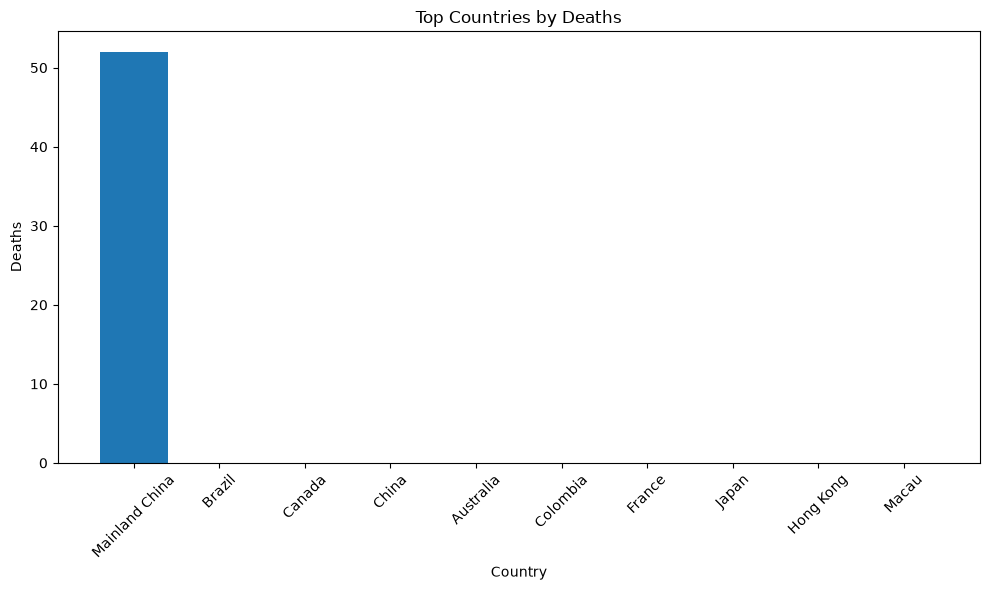

In [19]:
country_deaths = (
    df.groupby("Country")["Deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    country_deaths.index,
    country_deaths.values
)

plt.title("Top Countries by Deaths")
plt.xlabel("Country")
plt.ylabel("Deaths")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

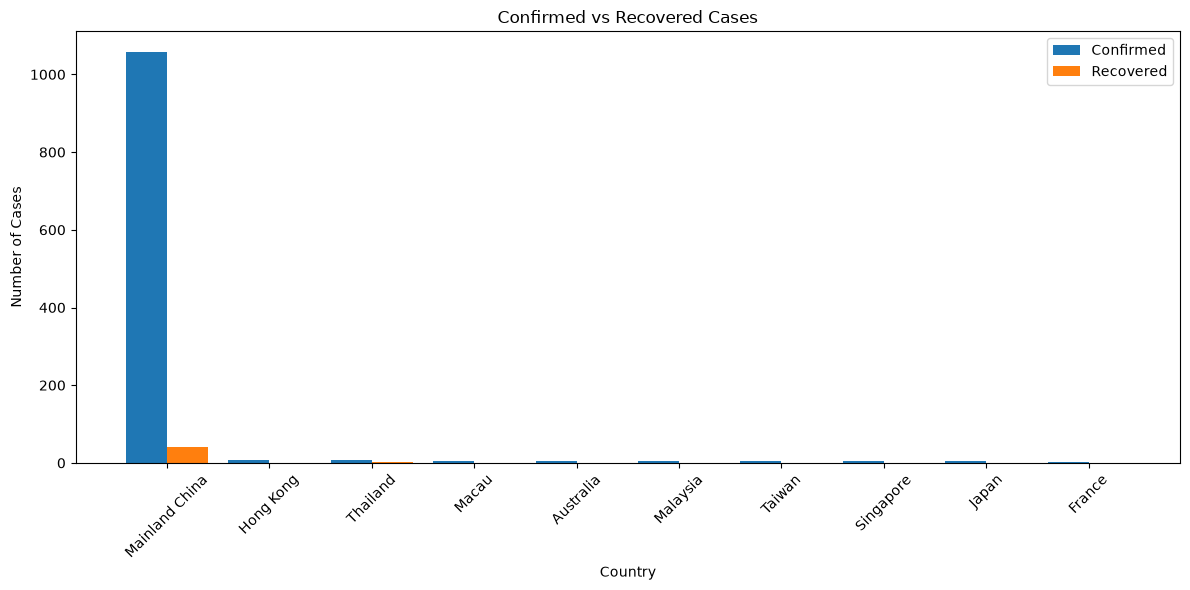

In [20]:
country_data = df.groupby("Country").agg({
    "Confirmed": "max",
    "Recovered": "max"
}).sort_values(
    "Confirmed",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

x = np.arange(len(country_data))

plt.bar(
    x - 0.2,
    country_data["Confirmed"],
    width=0.4,
    label="Confirmed"
)

plt.bar(
    x + 0.2,
    country_data["Recovered"],
    width=0.4,
    label="Recovered"
)

plt.xticks(x, country_data.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("Number of Cases")

plt.title("Confirmed vs Recovered Cases")

plt.legend()

plt.tight_layout()
plt.show()

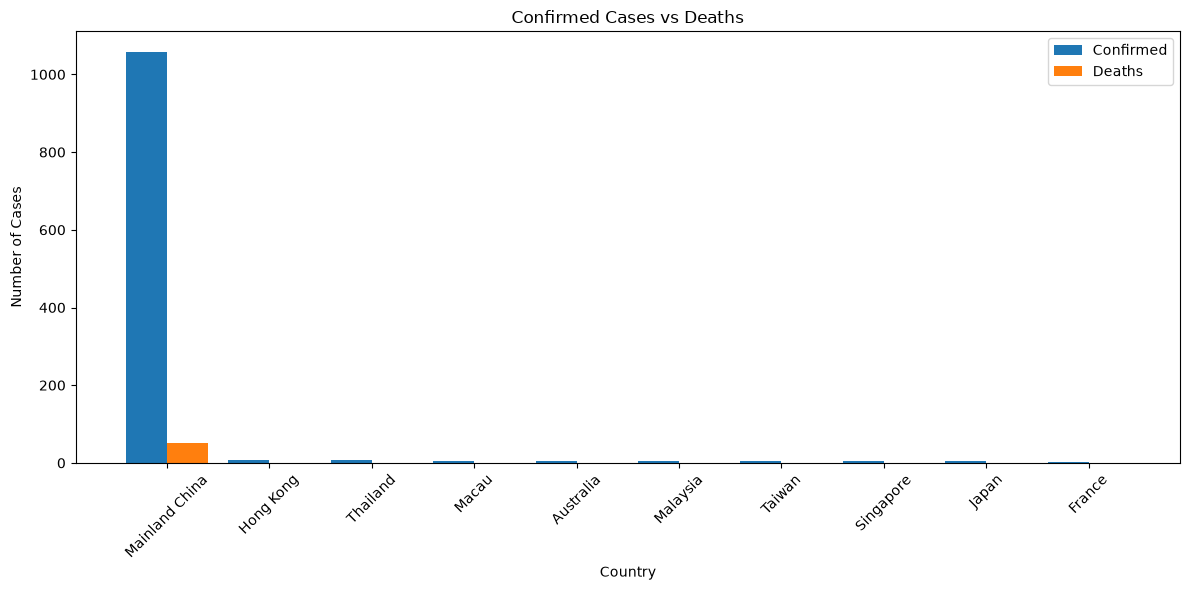

In [21]:
country_data = df.groupby("Country").agg({
    "Confirmed": "max",
    "Deaths": "max"
}).sort_values(
    "Confirmed",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

x = np.arange(len(country_data))

plt.bar(
    x - 0.2,
    country_data["Confirmed"],
    width=0.4,
    label="Confirmed"
)

plt.bar(
    x + 0.2,
    country_data["Deaths"],
    width=0.4,
    label="Deaths"
)

plt.xticks(
    x,
    country_data.index,
    rotation=45
)

plt.xlabel("Country")
plt.ylabel("Number of Cases")

plt.title("Confirmed Cases vs Deaths")

plt.legend()

plt.tight_layout()
plt.show()

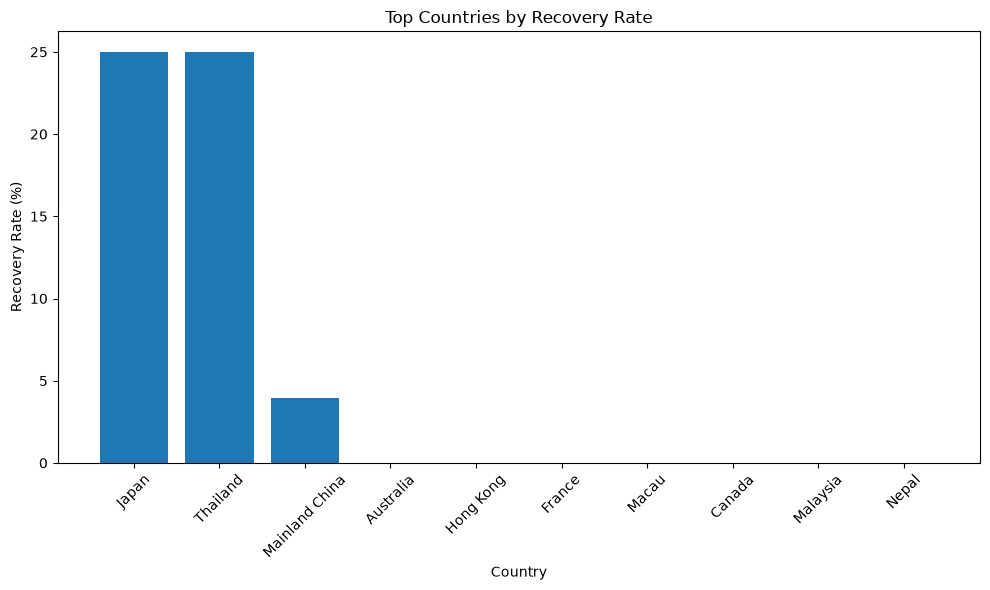

In [22]:
country_stats = df.groupby("Country").agg({
    "Confirmed": "max",
    "Recovered": "max"
})

country_stats["Recovery Rate"] = np.where(
    country_stats["Confirmed"] > 0,
    (
        country_stats["Recovered"]
        / country_stats["Confirmed"]
    ) * 100,
    0
)

top_recovery = (
    country_stats[
        country_stats["Confirmed"] > 0
    ]
    .sort_values(
        "Recovery Rate",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_recovery.index,
    top_recovery["Recovery Rate"]
)

plt.title("Top Countries by Recovery Rate")
plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

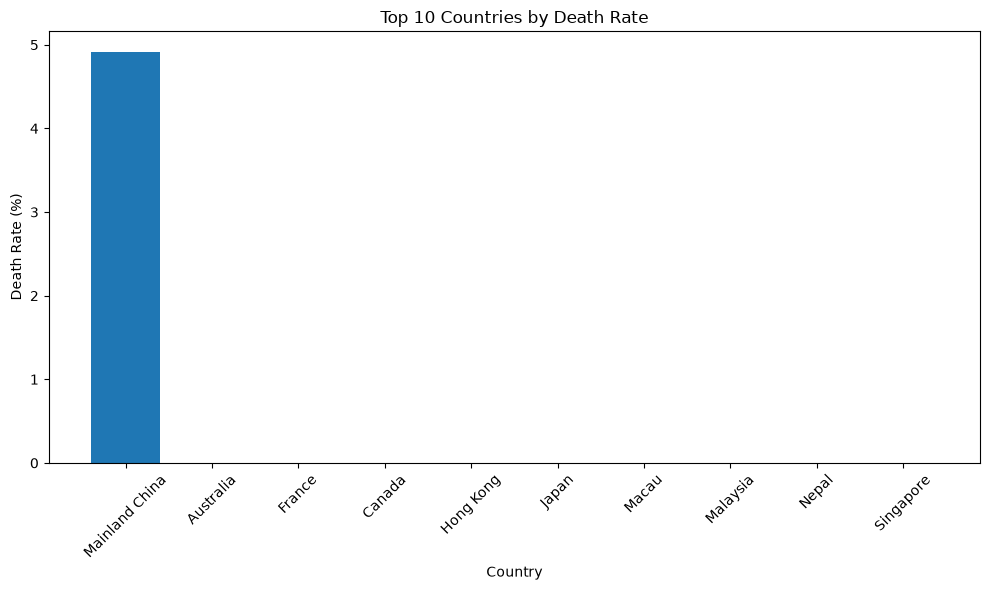

In [23]:
country_stats = df.groupby("Country").agg(
    Confirmed=("Confirmed", "max"),
    Deaths=("Deaths", "max")
)

# Calculate Death Rate
country_stats["Death Rate"] = (
    country_stats["Deaths"] /
    country_stats["Confirmed"].replace(0, np.nan)
) * 100

# Remove missing values
country_stats = country_stats.dropna(subset=["Death Rate"])

# Select top 10 countries by death rate
top_death_rate = country_stats.sort_values(
    by="Death Rate",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    top_death_rate.index,
    top_death_rate["Death Rate"]
)

plt.title("Top 10 Countries by Death Rate")
plt.xlabel("Country")
plt.ylabel("Death Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

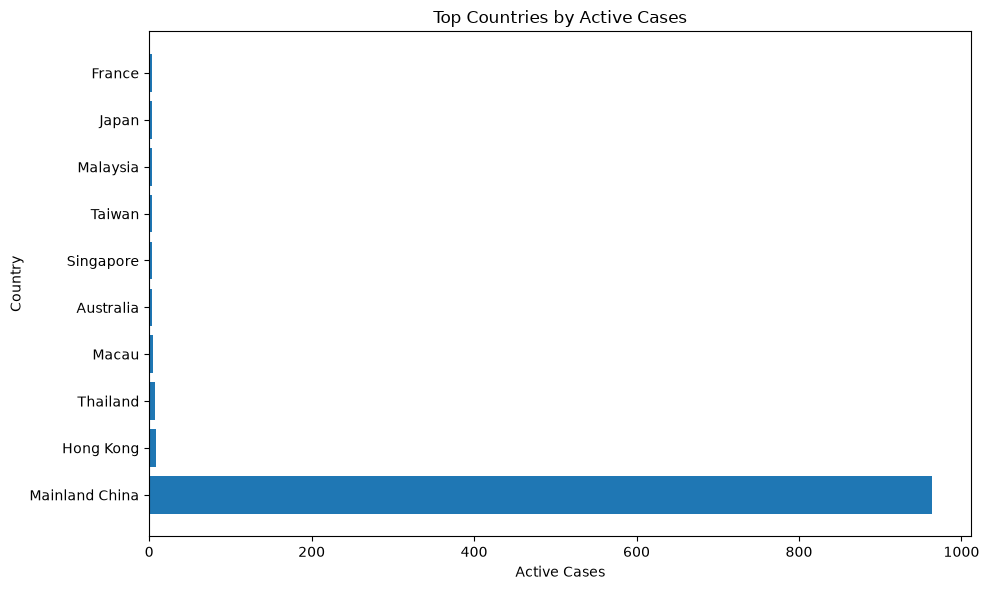

In [24]:
country_active = (
    df.groupby("Country")["Active Cases"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    country_active.index,
    country_active.values
)

plt.title("Top Countries by Active Cases")
plt.xlabel("Active Cases")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

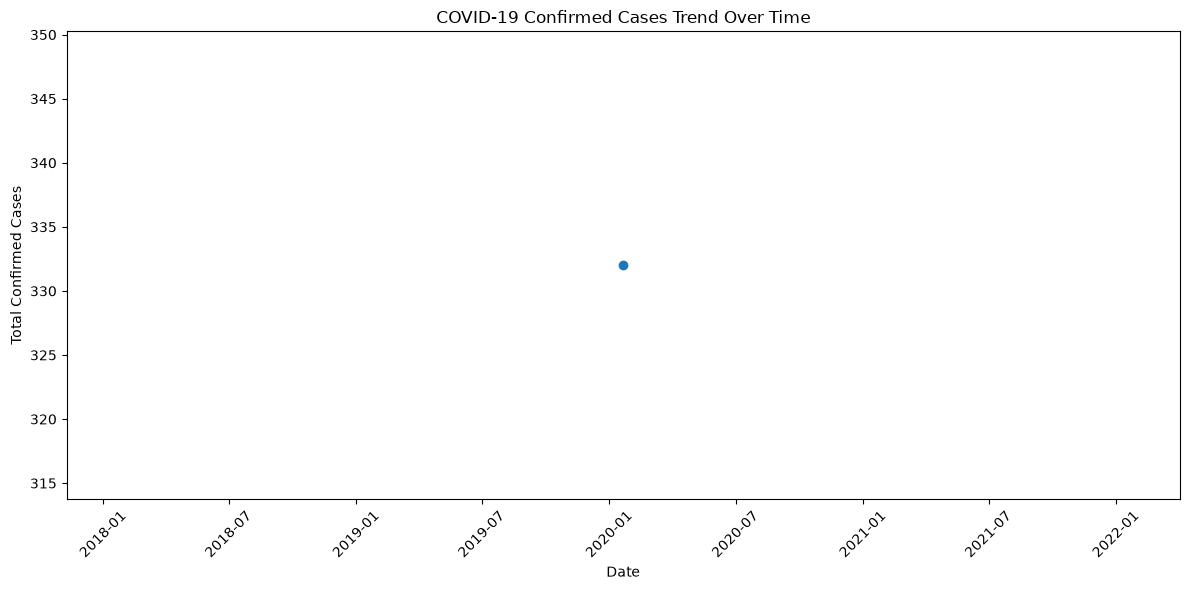

In [25]:
daily_cases = (
    df.groupby("Date last updated")["Confirmed"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_cases.index,
    daily_cases.values,
    marker="o"
)

plt.title("COVID-19 Confirmed Cases Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

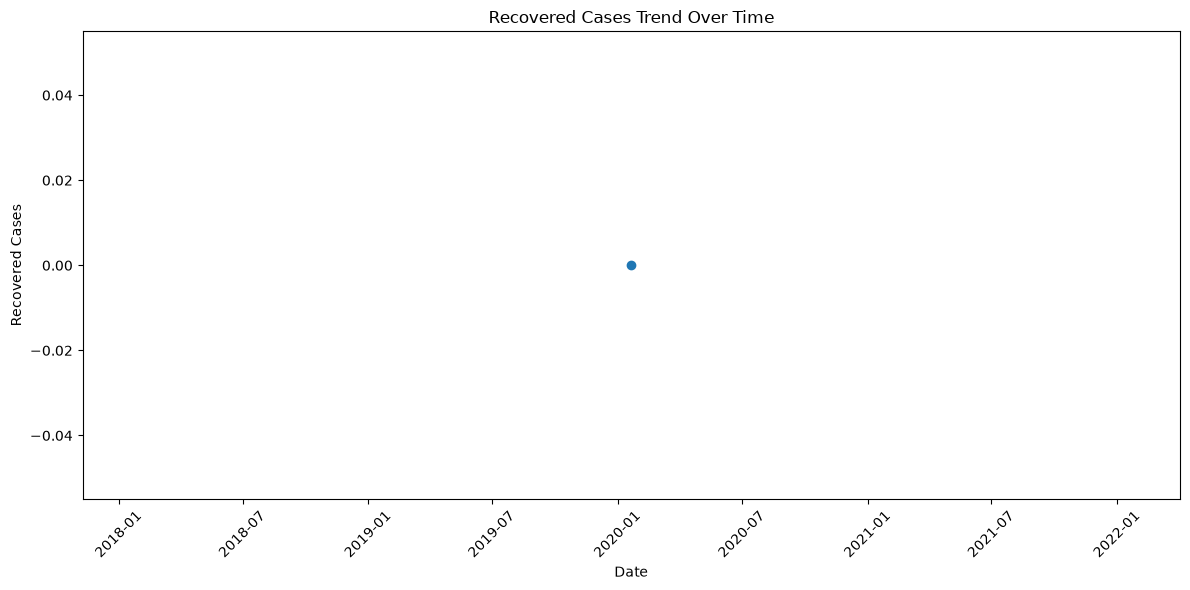

In [26]:
daily_recovered = (
    df.groupby("Date last updated")["Recovered"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_recovered.index,
    daily_recovered.values,
    marker="o"
)

plt.title("Recovered Cases Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Recovered Cases")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

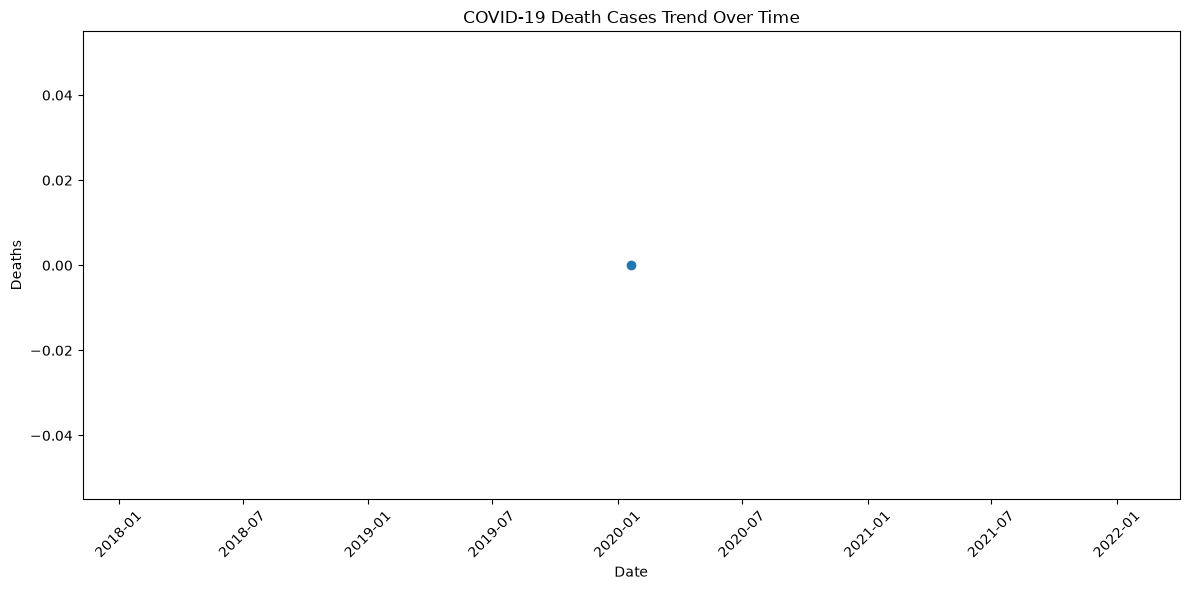

In [27]:
daily_deaths = (
    df.groupby("Date last updated")["Deaths"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_deaths.index,
    daily_deaths.values,
    marker="o"
)

plt.title("COVID-19 Death Cases Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Deaths")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

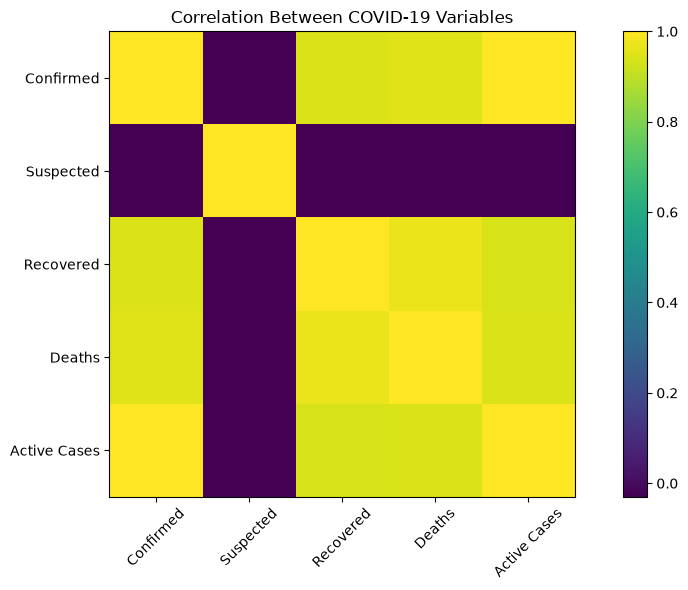

In [28]:
numerical_data = df[
    [
        "Confirmed",
        "Suspected",
        "Recovered",
        "Deaths",
        "Active Cases"
    ]
]

correlation = numerical_data.corr()

plt.figure(figsize=(10, 6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between COVID-19 Variables")

plt.tight_layout()
plt.show()

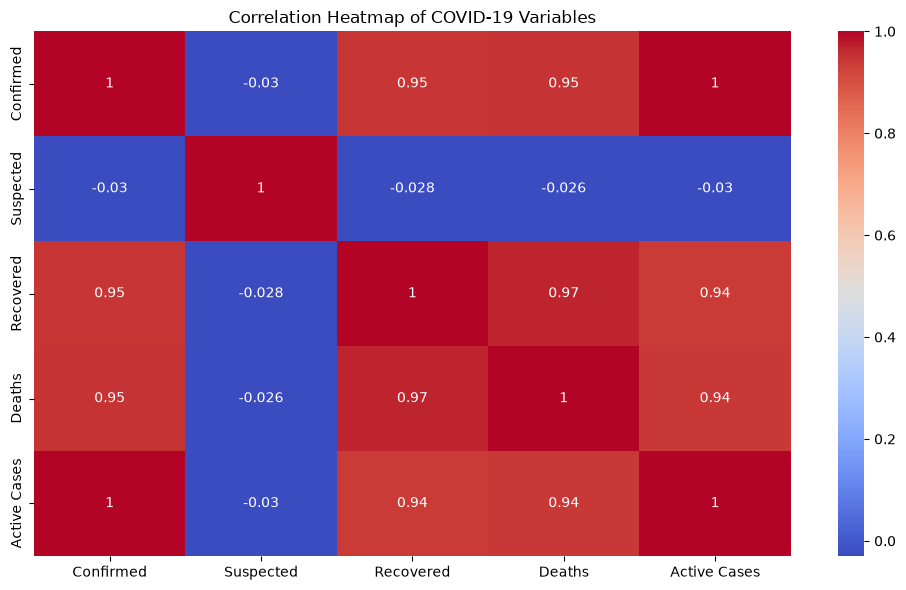

In [29]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[
        ["Confirmed", "Suspected", "Recovered",
         "Deaths", "Active Cases"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of COVID-19 Variables")
plt.tight_layout()
plt.show()

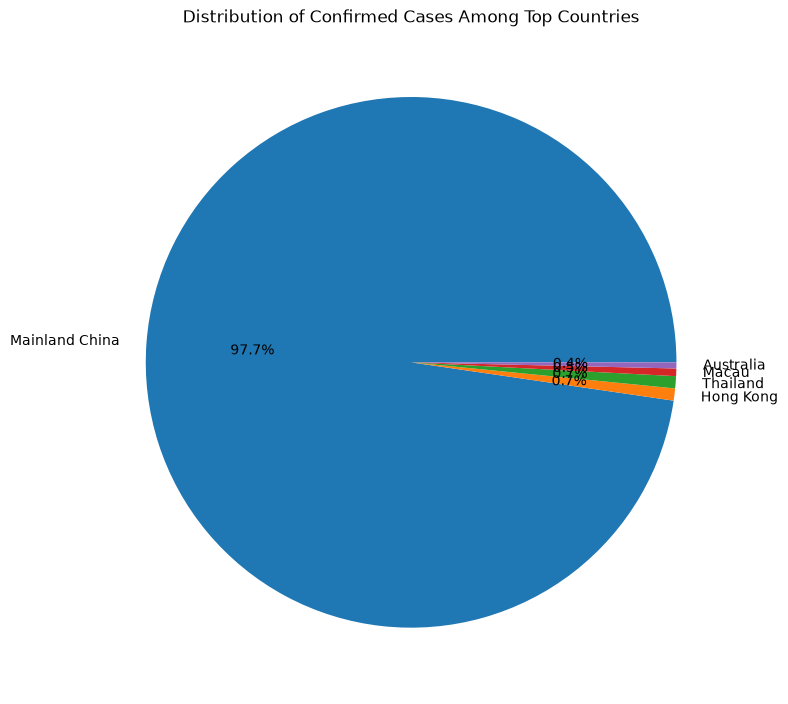

In [30]:
top_countries = (
    df.groupby("Country")["Confirmed"]
    .max()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 8))

plt.pie(
    top_countries.values,
    labels=top_countries.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Confirmed Cases Among Top Countries")

plt.tight_layout()
plt.show()

In [31]:
print("Total Confirmed Cases:", df["Confirmed"].max())

print("Total Recovered Cases:", df["Recovered"].max())

print("Total Deaths:", df["Deaths"].max())

print("Total Countries:", df["Country"].nunique())

print(
    "Total Provinces/States:",
    df["Province/State"].nunique()
)

Total Confirmed Cases: 1058.0
Total Recovered Cases: 42.0
Total Deaths: 52.0
Total Countries: 21
Total Provinces/States: 40
